In [16]:
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

True

In [17]:
llm = ChatGroq(model=os.getenv("GROQ_MODEL"),
        api_key=os.getenv("GROQ_API_KEY"))

In [18]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negitive'] 

In [5]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"]
    tone: Literal["angry", "frustrated", "disappointed", "calm"]
    urgency: Literal["low", "medium", "high"]

In [6]:
structured_model = llm.with_structured_output(SentimentSchema)
structured_model2 = llm.with_structured_output(DiagnosisSchema) 

In [19]:
structured_model

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000196A08BFB60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000196A0A84980>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'SentimentSchema', 'description': '', 'parameters': {'properties': {'sentiment': {'enum': ['positive', 'negitive'], 'type': 'string'}}, 'required': ['sentiment'], 'type': 'object'}}}], 'ls_structured_output_format': {'kwargs': {'method': 'function_calling'}, 'schema': {'type': 'function', 'function': {'name': 'SentimentSchema', 'description': '', 'parameters': {'properties': {'se

In [8]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negitive']
    diagnosis: dict 
    response: str

In [9]:
def find_sentiment(state: ReviewState):
    prompt = f"for the following review find out of the sentiment \n {state['review']}"
    sentiment = structured_model.invoke(prompt).sentiment
    return {"sentiment": sentiment}

In [10]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    return "positive_response" if state.get('sentiment') == 'positive' else "run_diagnosis"

def positive_response(state: ReviewState):
    prompt = f"Write a warm thank-you in response to this review:\n\n{state['review']}\n\nAlso, kindly ask the user to leave feedback on our website."
    response = llm.invoke(prompt).content
    return {"response": response}

def run_diagnosis(state: ReviewState):
    prompt = f"Diagnose this negative review:\n\n{state['review']}\n\nReturn issue_type, tone, and urgency."
    response = structured_model2.invoke(prompt)
    return {"diagnosis": response.model_dump()}

def negitive_response(state: ReviewState):
    diagnosis = state.get('diagnosis')
    
    # Failsafe check
    if diagnosis is None:
        raise KeyError(f"diagnosis missing; state keys: {list(state.keys())}")

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message."""
    response = llm.invoke(prompt).content
    return {"response": response}

In [12]:
state_graph = StateGraph(ReviewState)

state_graph.add_node('find_sentiment', find_sentiment)
state_graph.add_node('positive_response', positive_response)
state_graph.add_node('run_diagnosis', run_diagnosis)
state_graph.add_node('negitive_response', negitive_response)

state_graph.add_edge(START, 'find_sentiment')
state_graph.add_conditional_edges('find_sentiment', check_sentiment)
state_graph.add_edge('positive_response', END)
state_graph.add_edge('run_diagnosis', 'negitive_response')
state_graph.add_edge('negitive_response', END)

workflow = state_graph.compile()

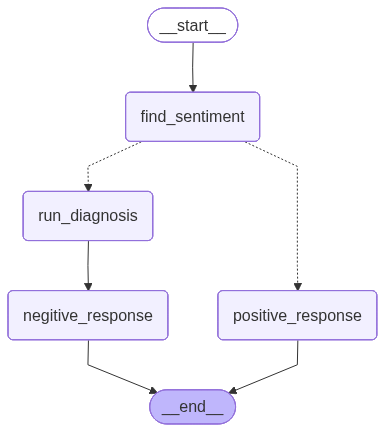

In [13]:
workflow

In [14]:
initial_state = {
    'review' : "the product was really good"
}

workflow.invoke(initial_state)

{'review': 'the product was really good',
 'sentiment': 'positive',
 'response': "Dear valued customer,\n\nWe're thrilled to hear that you're really happy with our product - that means the world to us! We're grateful for customers like you who appreciate the effort we put into creating high-quality products.\n\nAs a small token of our appreciation, we'd love to hear more about your experience with us. If you have a moment, could you please leave your feedback on our website? Your input will help us continue to improve and provide the best possible experience for you and our future customers.\n\nOnce again, thank you for your kind words and for choosing our product. We're honored to have customers like you and look forward to serving you again in the future.\n\nBest regards, [Your Name]"}

In [15]:
initial_state = {
    'review' : "the product was really bad"
}

workflow.invoke(initial_state)

{'review': 'the product was really bad',
 'sentiment': 'negitive',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': "I'm so sorry to hear that you're experiencing a bug issue and that it's causing frustration for you. I can imagine how annoying it must be, and I appreciate you reaching out to us for help.\n\nI want to assure you that we're taking your issue very seriously, especially since you've marked it as high urgency. I'm here to help you resolve this as quickly as possible.\n\nTo get started, could you please provide me with more details about the bug you're experiencing? This will help me to better understand the issue and work towards a solution. Please include any error messages you've seen, the steps you took leading up to the issue, and any other relevant information.\n\nIn the meantime, I'll do my best to escalate your issue to our technical team and get a resolution in place as soon as possible. If there's anything we can do to prevent 